# Exploratory Data Analysis (EDA)

This section explores patterns and trends in the Netflix dataset, including content distribution, ratings, genres, and production countries.

In [1]:
#import pandas library
import pandas as pd

In [2]:
df = pd.read_csv("cleaned_netflix_dataset.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The dataset contains information about Netflix titles, including movies and TV shows. It includes details such as title, type, cast, country, release year, rating, and genre.

In [5]:
df['date_added'] = df['date_added'].str.strip()  # remove extra spaces
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The date_added column contained inconsistent formatting with leading spaces. These were cleaned using string stripping before converting the column to datetime format. Invalid date entries were handled using coercion and removed where necessary.

### Content Added Over Time

In [8]:
df['year_added'] = df['date_added'].dt.year

content_by_year = df['year_added'].value_counts().sort_index()

content_by_year

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

Content on Netflix increased rapidly after 2015, peaking around 2019–2020. This reflects Netflix’s expansion and increased content production during that period.

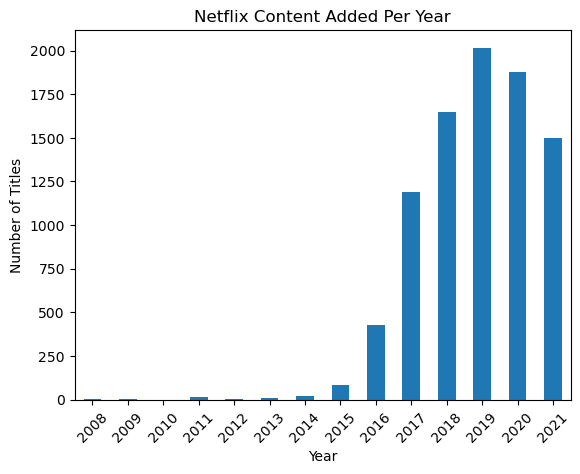

In [9]:
import matplotlib.pyplot as plt

content_by_year.plot(kind='bar')

plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

The number of titles added to Netflix increased gradually from 2008, with a sharp rise beginning in 2016. The platform experienced peak content additions in 2019, reflecting its aggressive expansion strategy. A slight decline is observed after 2019, but content additions remain significantly higher than earlier years.

### Movies vs TV Shows Distribution

In [10]:
#Count each type
type_counts = df['type'].value_counts()
type_counts

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

The dataset shows that movies (6131) significantly outnumber TV shows (2666), indicating that Netflix has a stronger focus on movie content.

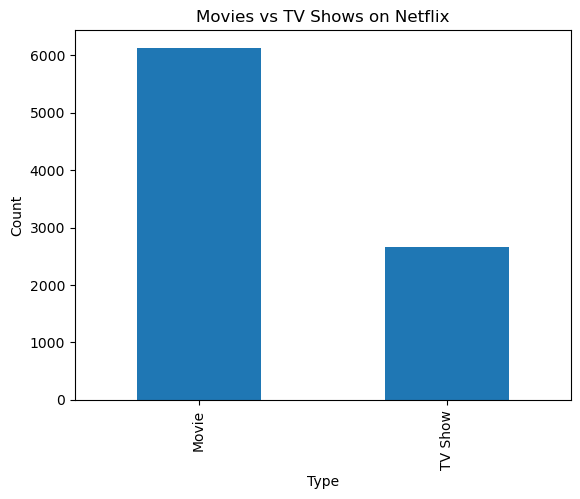

In [13]:
type_counts.plot(kind='bar')

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

The analysis shows that movies dominate the Netflix catalog, accounting for a significantly larger portion compared to TV shows. This suggests that Netflix prioritizes movie content, although TV shows still represent a substantial share of the platform’s offerings.

### Top Content-Producing Countries

In [19]:
#Count by country
df_no_unknown = df[df['country'] != 'Unknown']

df_no_unknown['country'].value_counts().head(10)

country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

The United States produces the highest number of titles, followed by India and the United Kingdom. This shows a strong dominance of US content on the platform.

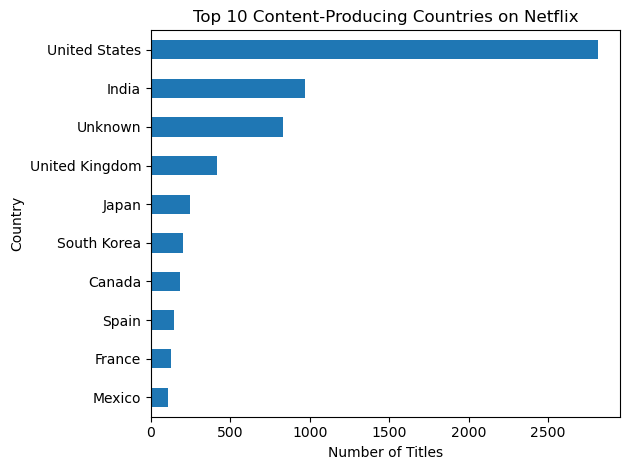

In [21]:
plt.figure()

country_counts.sort_values().plot(kind='barh')

plt.title('Top 10 Content-Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

The United States produces the majority of Netflix content, followed by India and the United Kingdom. This highlights Netflix’s strong American foundation while also showing increasing contributions from other countries. A significant portion of the dataset contains missing country information labeled as “Unknown,” which may affect the accuracy of the analysis.

### Most Common Genres

In [24]:
#Top genres
genre_counts = df['listed_in'].value_counts().head(10)
genre_counts

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

Most content is rated TV-MA and TV-14, indicating that Netflix primarily targets mature and young adult audiences.

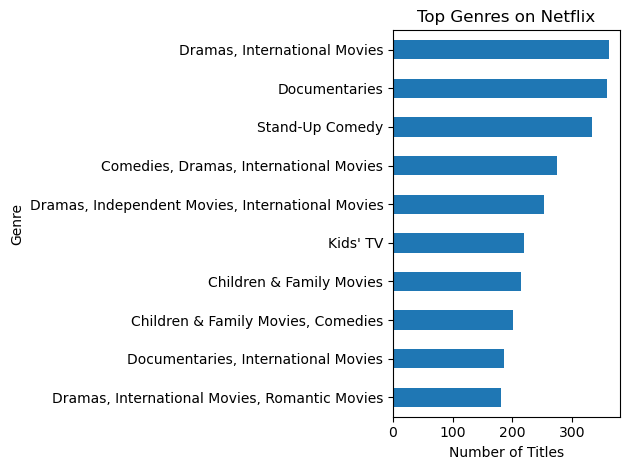

In [28]:
genre_counts.sort_values().plot(kind='barh')

plt.title('Top Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The analysis reveals that drama is the most dominant genre on Netflix, often combined with international content. Documentaries and stand-up comedy also form a significant portion of the catalog. Additionally, the presence of children and family content highlights Netflix’s effort to cater to a wide audience across different age groups.

### Rating Distribution

In [29]:
#Count ratings
rating_counts = df['rating'].value_counts()
rating_counts

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Most content is rated TV-MA and TV-14, indicating that Netflix primarily targets mature and young adult audiences.

In [32]:
# Remove rows where rating looks like duration
df = df[~df['rating'].str.contains('min', na=False)]

In [33]:
rating_counts = df['rating'].value_counts()
rating_counts

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
Name: count, dtype: int64

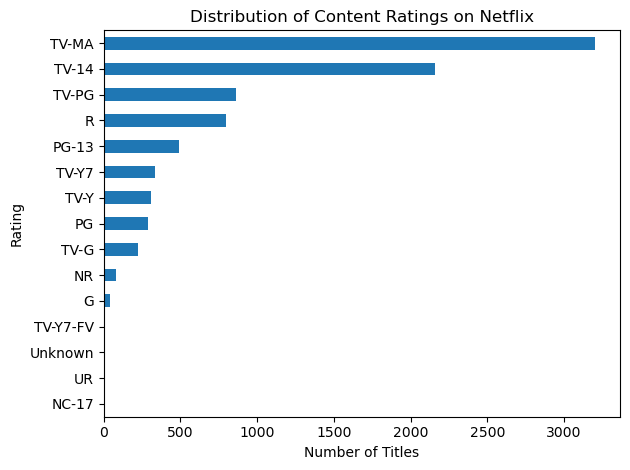

In [34]:
rating_counts.sort_values().plot(kind='barh')

plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

The rating distribution shows that Netflix content is heavily concentrated in the TV-MA and TV-14 categories, indicating a strong focus on mature and young adult audiences. While there is a presence of family-friendly and children's content, it represents a significantly smaller portion of the catalog. This suggests that Netflix prioritizes content aimed at older viewers. Lower-frequency ratings such as NC-17 and UR appear rarely, indicating limited inclusion of highly restricted or unrated content on the platform.